# Funding-aware perpetual backtests

**Use case: [Improve your backtest](https://aperiodic.io/use-cases/improve-your-backtest)**

A perpetual-futures position does not only earn the price move — it also pays or
receives **funding** at discrete settlement prints. A price-only backtest ignores
those cash flows and can misattribute carry to trading alpha, especially for a
persistently long strategy in a rising market. This notebook isolates how
*realised* funding changes strategy PnL by comparing a **price-only** backtest
with **price + funding** and with **price + funding + simplified costs**.

We use **Binance BTC perpetuals** (`perpetual-BTC-USDT:USDT`) at **5-minute**
resolution over **May 2025**, the window served by the shared `DEMO-KEY` preview
slice.

> **One month is an illustration, not evidence.** Every Sharpe ratio, return, and
> drawdown below comes from a single month of 5-minute data. Read them as a
> worked example of *how funding enters PnL*, never as proof of a durable edge.

**Background reading**
- Aperiodic derivatives metrics: https://aperiodic.io/metrics/derivatives
- Binance Academy, funding rates: https://www.binance.com/en/academy/articles/what-are-funding-rates-in-crypto-markets

## 1. Funding is part of perp PnL

Perpetual swaps use a **funding** mechanism to keep the contract tethered to the
spot/index price:

- When funding is **positive**, **longs pay shorts**. When it is **negative**,
  **shorts pay longs**.
- Funding is exchanged at **discrete prints** (Binance settles every 8 hours),
  not continuously. It accrues to whatever position is held *at the print*.
- We use **realised** funding only. The catalogue exposes no predicted-funding
  metric, so nothing here forecasts the next print — we account for prints that
  already happened.

Omitting these cash flows inflates a long-biased backtest during bullish,
positive-funding regimes: the strategy looks like it earned price alpha when part
of the "PnL" was really unpaid funding.

In [1]:
from __future__ import annotations

import os
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aperiodic import get_derivative_metrics, get_ohlcv

sns.set_theme(style="whitegrid", context="talk", palette="deep")
pd.options.display.float_format = "{:,.6f}".format
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Configuration

Uppercase constants hold the public parameters. The API key resolves **inline
value → `APERIODIC_API_KEY` → `DEMO-KEY`**; with no key the notebook runs
end-to-end on the `DEMO-KEY` preview slice.

In [2]:
EXCHANGE = "binance-futures"
SYMBOL = "perpetual-BTC-USDT:USDT"
INTERVAL = "5m"
START_DATE = date(2025, 5, 1)
END_DATE = date(2025, 5, 31)
TIMESTAMP = "exchange"
START_TS = pd.Timestamp(START_DATE)
END_TS = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)

# One-way flat cost assumption, in basis points, for the cost-aware backtest.
FLAT_COST_BPS = 5.0
# Lookback (bars) for the transparent toy momentum signal; 12 bars = 1 hour.
MOMENTUM_LOOKBACK = 12
# Near-zero band (bps) for shading the funding regime chart.
FUNDING_ZERO_BAND_BPS = 0.5

API_KEY = "..."  # Set your key here, or via the APERIODIC_API_KEY env var
if API_KEY == "...":
    API_KEY = os.environ.get("APERIODIC_API_KEY", "DEMO-KEY")

# Only the shared "DEMO-KEY" runs against the preview endpoint. Provide your own
# key (above or via APERIODIC_API_KEY) to use the standard endpoint.
USE_PREVIEW = API_KEY == "DEMO-KEY"

print(f"Exchange / symbol : {EXCHANGE} / {SYMBOL}")
print(f"Interval / window : {INTERVAL} | {START_DATE} → {END_DATE}")
print(f"Mode              : {'preview (DEMO-KEY)' if USE_PREVIEW else 'standard endpoint'}")

Exchange / symbol : binance-futures / perpetual-BTC-USDT:USDT
Interval / window : 5m | 2025-05-01 → 2025-05-31
Mode              : standard endpoint


## Helper functions

`clip_window` and `format_time_axis` match the introductory notebooks;
`run_position_backtest` is the same 5-minute-annualised backtest used in
`most-predictive.py` and `alpha-discovery.py`; `funding_prints` maps the reported
rate to discrete settlement events; and `audit_columns` prints the fetched schema
and fails loudly if a required field is absent.

In [3]:
def clip_window(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out = out.loc[(out["time"] >= START_TS) & (out["time"] < END_TS)]
    return out.sort_values("time").reset_index(drop=True)


def format_time_axis(ax):
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)


def audit_columns(frames: dict[str, tuple[pd.DataFrame, list[str]]]) -> None:
    lines, problems = [], []
    for name, (frame, required) in frames.items():
        cols = sorted(map(str, frame.columns))
        missing = [c for c in required if c not in frame.columns]
        lines.append(f"- {name:<14} {len(frame):>5} rows | columns={cols}")
        if missing:
            problems.append(f"{name} missing {missing}")
    report = "Fetched schema:\n" + "\n".join(lines)
    print(report)
    if problems:
        raise KeyError("; ".join(problems) + "\n" + report)


def funding_settlement_mask(frame: pd.DataFrame) -> pd.Series:
    """A funding print is a discrete settlement event. Binance USDT-margined
    perpetuals settle every 8 hours (00:00, 08:00, 16:00 UTC), so we accrue the
    reported rate at those bars only and never invent a funding rate on every
    5-minute row — robust whether the API reports a step or a continuously
    updating rate between settlements. If the standard schedule is absent (a
    non-standard cadence), fall back to detecting a change in the reported rate."""
    t = frame["time"]
    scheduled = t.dt.hour.isin([0, 8, 16]) & (t.dt.minute == 0)
    if int(scheduled.sum()) >= 3:
        return scheduled
    fr = frame["funding_rate"]
    return fr.notna() & fr.ne(fr.shift())


def run_position_backtest(
    timestamps: pd.Series,
    position: np.ndarray,
    forward_return: np.ndarray,
    cost_bps_one_way: float | np.ndarray = 0.0,
) -> tuple[pd.DataFrame, dict]:
    """Vectorised long/short backtest; annualisation assumes 5-minute bars."""
    position = np.asarray(position, dtype=np.float64)
    forward_return = np.asarray(forward_return, dtype=np.float64)

    gross_pnl = position * forward_return
    turnover = np.abs(np.diff(position, prepend=0.0))
    cost = turnover * np.asarray(cost_bps_one_way, dtype=np.float64) / 1e4
    net_pnl = gross_pnl - cost
    equity = np.cumprod(1.0 + net_pnl)

    if equity.size == 0:
        bt_frame = pd.DataFrame({"timestamp": timestamps.to_numpy(), "equity_curve": equity})
        return bt_frame, {"annualized_sharpe": 0.0, "net_return_pct": 0.0, "max_drawdown_pct": 0.0}

    running_max = np.maximum.accumulate(equity)
    drawdowns = (equity - running_max) / running_max
    max_drawdown_pct = float(np.min(drawdowns)) * 100.0

    bars_per_year = 288 * 365
    mean_ret = float(np.mean(net_pnl))
    std_ret = float(np.std(net_pnl, ddof=1)) if len(net_pnl) > 1 else 1.0
    annualized_sharpe = (mean_ret / std_ret) * np.sqrt(bars_per_year) if std_ret > 0 else 0.0
    net_return_pct = float((equity[-1] / equity[0] - 1.0) * 100.0)

    bt_frame = pd.DataFrame({"timestamp": timestamps.to_numpy(), "equity_curve": equity})
    bt_summary = {
        "annualized_sharpe": float(annualized_sharpe),
        "net_return_pct": net_return_pct,
        "max_drawdown_pct": max_drawdown_pct,
    }
    return bt_frame, bt_summary

## 3. Fetch price and realised funding

The price and funding requests share the common arguments (`api_key`, `preview`,
`timestamp`, `interval`, `exchange`, `symbol`, `start_date`, `end_date`,
`output="pandas"`, `show_progress=False`). Basis and open interest are fetched as
optional context only — they are not dependencies of the core funding analysis.

In [4]:
COMMON = dict(
    api_key=API_KEY,
    preview=USE_PREVIEW,
    timestamp=TIMESTAMP,
    interval=INTERVAL,
    exchange=EXCHANGE,
    symbol=SYMBOL,
    start_date=START_DATE,
    end_date=END_DATE,
    output="pandas",
    show_progress=False,
)

ohlcv = clip_window(get_ohlcv(**COMMON))
funding = clip_window(get_derivative_metrics(metric="funding", **COMMON))
basis = clip_window(get_derivative_metrics(metric="basis", **COMMON))  # optional context
open_interest = clip_window(get_derivative_metrics(metric="open_interest", **COMMON))  # optional context

audit_columns(
    {
        "ohlcv": (ohlcv, ["time", "close"]),
        "funding": (funding, ["time", "funding_rate"]),
    }
)
print("basis columns   :", sorted(map(str, basis.columns)))
print("open_interest   :", sorted(map(str, open_interest.columns)))

Fetched schema:
- ohlcv           8928 rows | columns=['close', 'high', 'low', 'open', 'time', 'volume', 'volume_notional']
- funding         8928 rows | columns=['funding_rate', 'funding_rate_avg_update_interval', 'funding_rate_update_frequency', 'time']
basis columns   : ['basis', 'basis_bps', 'basis_bps_std', 'basis_mean', 'mark_price_spread', 'mark_price_spread_bps', 'mark_price_spread_bps_std', 'mark_price_spread_mean', 'time']
open_interest   : ['oi_price_change_ratio', 'open_interest', 'open_interest_pct_change', 'open_interest_volatility', 'time']


In [5]:
# Core frame: price joined to realised funding on `time`. Keep the funding events
# at their native timestamps; identify discrete prints via change-detection.
df = ohlcv[["time", "close"]].merge(funding[["time", "funding_rate"]], on="time", how="inner").sort_values("time")
df = df.reset_index(drop=True)
# Forward-fill the reported rate for display/accrual (handles sparse reporting);
# never pull later values backwards.
df["funding_rate_ff"] = df["funding_rate"].ffill()
df["funding_rate_bps"] = df["funding_rate_ff"] * 1e4
df["is_print"] = funding_settlement_mask(df)
df["ret"] = df["close"].pct_change()

# Optional context, only if the columns are present.
for ctx, col in [(basis, "basis_bps"), (open_interest, "open_interest")]:
    if col in ctx.columns:
        df = df.merge(ctx[["time", col]], on="time", how="left")

prints = df.loc[df["is_print"], ["time", "funding_rate_ff", "funding_rate_bps"]].reset_index(drop=True)
coverage = pd.Series(
    {
        "Rows (5m bars)": len(df),
        "Funding prints": int(df["is_print"].sum()),
        "Start": df["time"].min(),
        "End": df["time"].max(),
        "Mean funding print (bps)": prints["funding_rate_bps"].mean(),
        "Share of positive prints": (prints["funding_rate_ff"] > 0).mean(),
        "Median basis (bps)": df["basis_bps"].median() if "basis_bps" in df else np.nan,
        "Median open interest": df["open_interest"].median() if "open_interest" in df else np.nan,
    }
)
coverage

Rows (5m bars)                             8928
Funding prints                               93
Start                       2025-05-01 00:00:00
End                         2025-05-31 23:55:00
Mean funding print (bps)               0.464571
Share of positive prints               0.903226
Median basis (bps)                    -4.212593
Median open interest              82,897.793500
dtype: object

## Chart 1 — Funding regimes

The reported funding rate through May 2025, in basis points, with positive
(longs pay), negative (shorts pay), and near-zero regimes shaded. Because the
rate is reported as a step that resets each settlement, we mark the actual
**print** events rather than interpolating a continuous series.

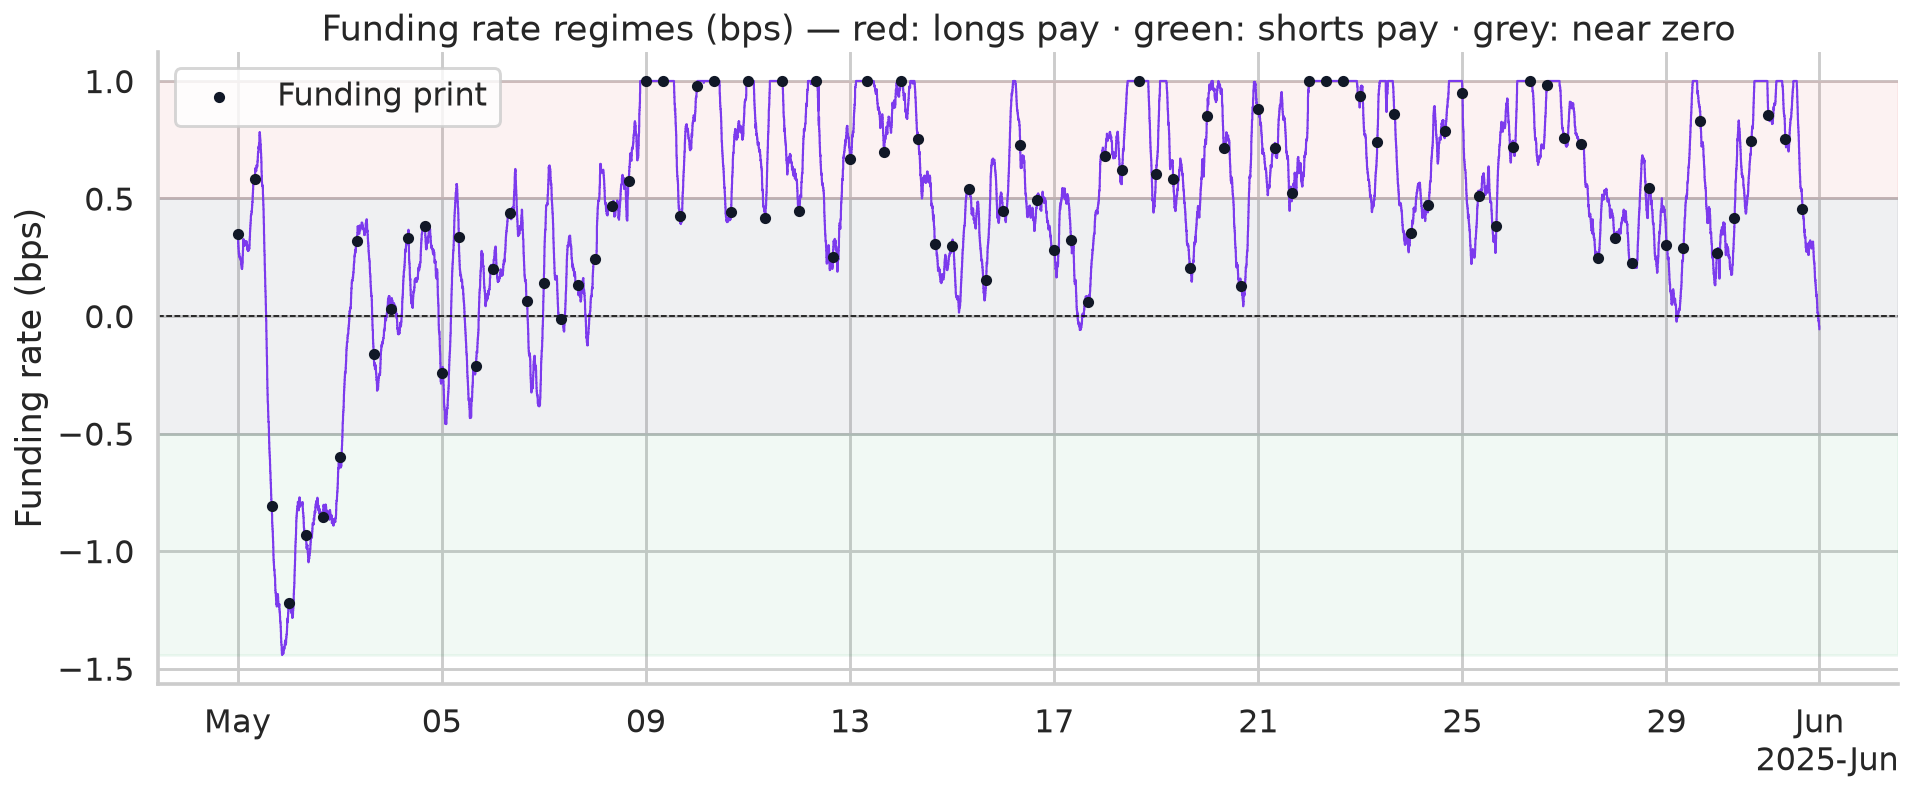

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.axhspan(FUNDING_ZERO_BAND_BPS, df["funding_rate_bps"].max(), color="#dc2626", alpha=0.06)
ax.axhspan(df["funding_rate_bps"].min(), -FUNDING_ZERO_BAND_BPS, color="#16a34a", alpha=0.06)
ax.axhspan(-FUNDING_ZERO_BAND_BPS, FUNDING_ZERO_BAND_BPS, color="#6b7280", alpha=0.10)
ax.step(df["time"], df["funding_rate_bps"], where="post", color="#7c3aed", linewidth=1.1)
ax.scatter(prints["time"], prints["funding_rate_bps"], s=18, color="#111827", zorder=5, label="Funding print")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Funding rate regimes (bps) — red: longs pay · green: shorts pay · grey: near zero")
ax.set_ylabel("Funding rate (bps)")
ax.legend(frameon=True)
format_time_axis(ax)
plt.tight_layout()

## Chart 2 — Cumulative funding for a constant long

Hold a **constant unit long** and accrue realised funding at each print. A long
**pays** funding when the rate is positive, so the realised funding cash flow at
a print is

> `funding_pnl = -position × funding_rate`   (position = +1 here)

A downward-sloping curve therefore means the long is *paying* to hold — carry
that a price-only backtest never subtracts.

Net funding for a constant unit long over the window: -0.4321% of notional


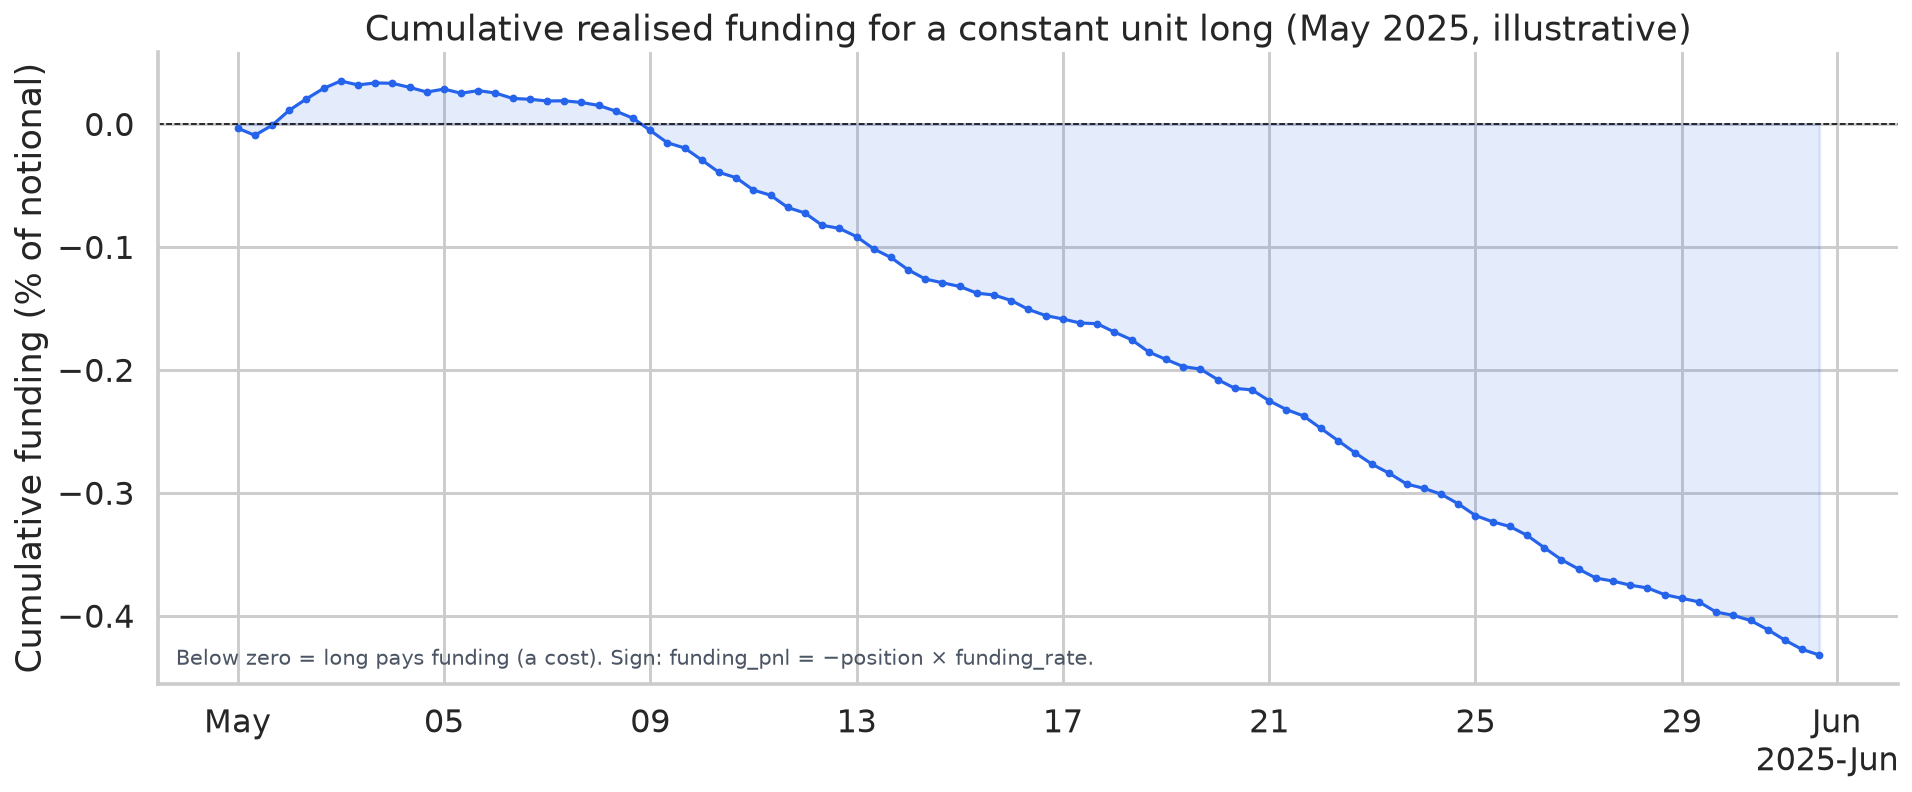

In [7]:
prints = prints.copy()
prints["cum_funding_unit_long"] = (-prints["funding_rate_ff"]).cumsum()
prints["cum_funding_unit_long_pct"] = prints["cum_funding_unit_long"] * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prints["time"], prints["cum_funding_unit_long_pct"], color="#2563eb", linewidth=1.6, marker="o", markersize=3)
ax.fill_between(prints["time"], prints["cum_funding_unit_long_pct"], alpha=0.12, color="#2563eb")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_title("Cumulative realised funding for a constant unit long (May 2025, illustrative)")
ax.set_ylabel("Cumulative funding (% of notional)")
ax.text(
    0.01,
    0.03,
    "Below zero = long pays funding (a cost). Sign: funding_pnl = −position × funding_rate.",
    transform=ax.transAxes,
    fontsize=11,
    color="#4b5563",
)
format_time_axis(ax)
plt.tight_layout()

print(f"Net funding for a constant unit long over the window: {prints['cum_funding_unit_long_pct'].iloc[-1]:.4f}% of notional")

## 6. Compare three backtests

A transparent toy momentum signal — the sign of the mean return over the last
`MOMENTUM_LOOKBACK` bars — is traded three ways. `run_position_backtest` handles
price and turnover-cost accounting; realised funding is added **as a per-bar cash
flow at print bars only**, by adjusting the return leg rather than the cost leg,
so turnover is never double-counted:

> `forward_return_with_funding = forward_return − funding_rate · is_print`

so that `position × (−funding_rate)` is credited/debited exactly at each print.

| scenario                     |   annualized_sharpe |   net_return_pct |   max_drawdown_pct |   funding_contribution_pct |
|:-----------------------------|--------------------:|-----------------:|-------------------:|---------------------------:|
| Price only                   |            0.958175 |          2.47313 |           -6.00429 |                    0       |
| Price + funding              |            0.946796 |          2.4362  |           -6.0208  |                   -0.03607 |
| Price + funding + 5bps costs |          -36.545    |        -70.1803  |          -70.3568  |                   -0.03607 |


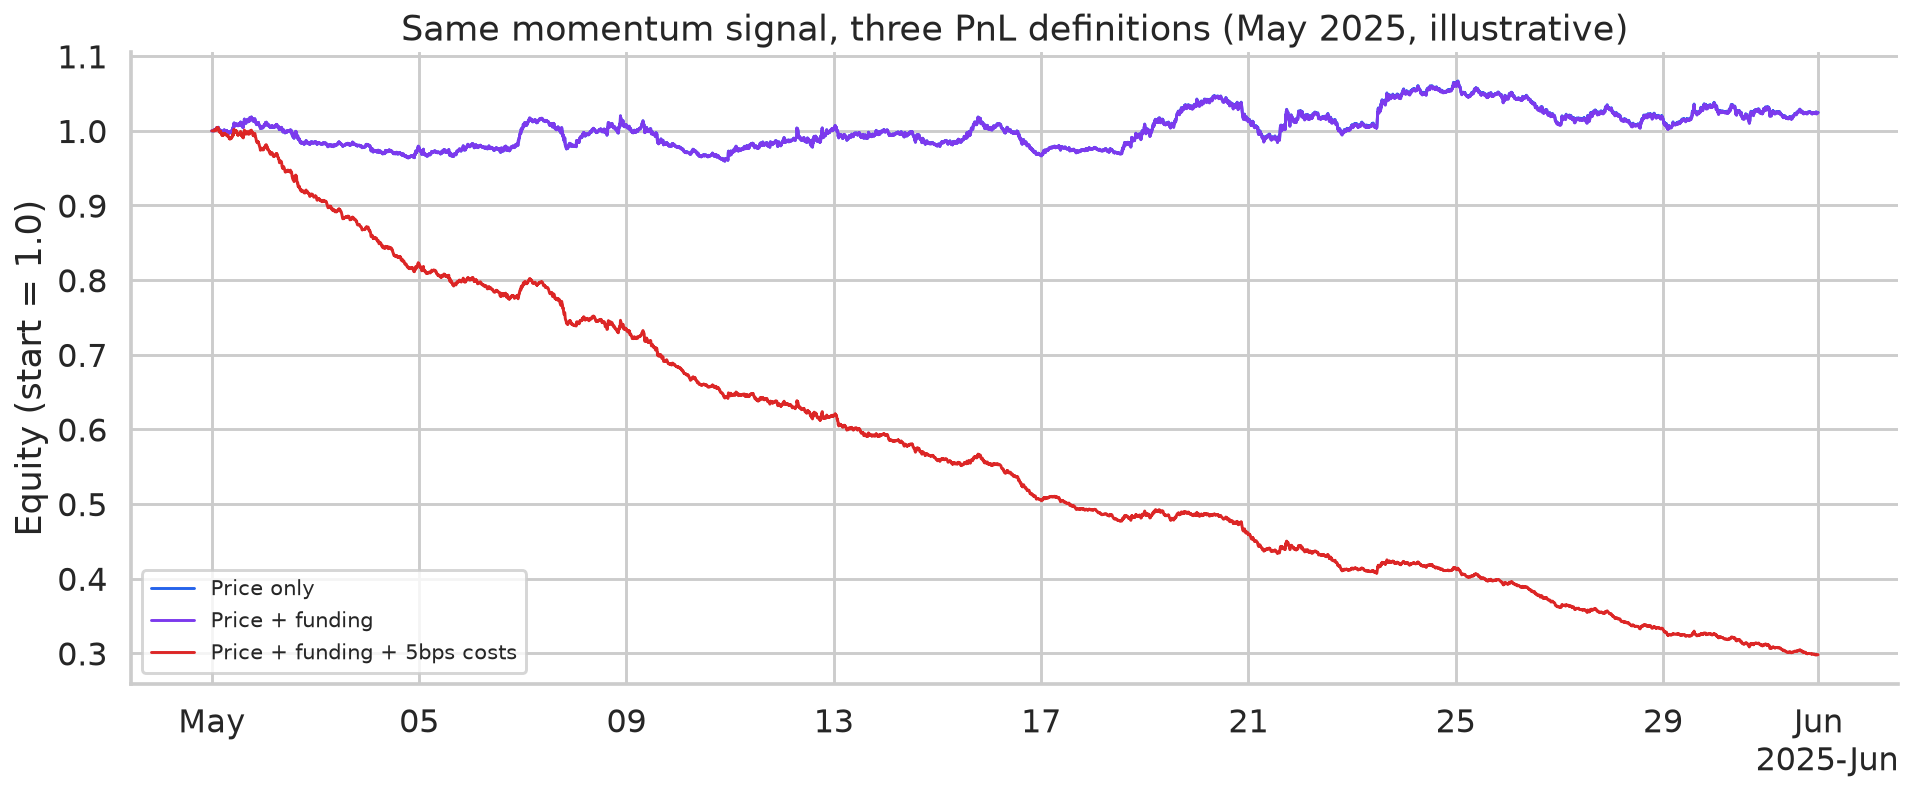

In [8]:
bt = df.reset_index(drop=True)
forward_return = bt["close"].pct_change().shift(-1)             # return from t to t+1
momentum = bt["ret"].rolling(MOMENTUM_LOOKBACK).mean()          # info up to bar t only
position = np.sign(momentum).fillna(0.0).to_numpy()

# Realised funding applied to the held position at settlement bars only.
funding_leg = bt["funding_rate_ff"].to_numpy() * bt["is_print"].to_numpy().astype(float)
fret = forward_return.to_numpy()
fret_with_funding = fret - funding_leg

valid = np.isfinite(position) & np.isfinite(fret)
ts = bt.loc[valid, "time"]
pos_v = np.nan_to_num(position[valid])
fret_v = np.nan_to_num(fret[valid])
fret_fund_v = np.nan_to_num(fret_with_funding[valid])

scenarios = {
    "Price only": (fret_v, 0.0, "#2563eb"),
    "Price + funding": (fret_fund_v, 0.0, "#7c3aed"),
    f"Price + funding + {FLAT_COST_BPS:g}bps costs": (fret_fund_v, FLAT_COST_BPS, "#dc2626"),
}

fig, ax = plt.subplots(figsize=(14, 6))
rows = []
for label, (returns, cost, color) in scenarios.items():
    frame, summ = run_position_backtest(ts, pos_v, returns, cost_bps_one_way=cost)
    ax.plot(frame["timestamp"], frame["equity_curve"], linewidth=1.5, color=color, label=label)
    # Additive realised-funding contribution to *this* position over the window.
    funding_contribution_pct = float(np.sum(-pos_v * funding_leg[valid]) * 100.0)
    rows.append(
        {
            "scenario": label,
            "annualized_sharpe": summ["annualized_sharpe"],
            "net_return_pct": summ["net_return_pct"],
            "max_drawdown_pct": summ["max_drawdown_pct"],
            "funding_contribution_pct": funding_contribution_pct if "funding" in label else 0.0,
        }
    )
ax.set_title("Same momentum signal, three PnL definitions (May 2025, illustrative)")
ax.set_ylabel("Equity (start = 1.0)")
ax.legend(frameon=True, fontsize=11)
format_time_axis(ax)
plt.tight_layout()

summary_table = pd.DataFrame(rows)
print(summary_table.to_markdown(index=False))

## Chart 3 — Funding as a signal

As a bonus diagnostic — a bridge to alpha research, **not** a tradable
conclusion — test `position = -sign(funding_rate)` (fade the crowd paying to hold).
The rate at bar *t* is known at *t*, so trading the *t → t+1* return uses no
look-ahead; between prints we forward-fill the latest observed rate.

Bridge to alpha research only — one month, one instrument, no costs. See notebooks/alpha-discovery.py for the full search framework.


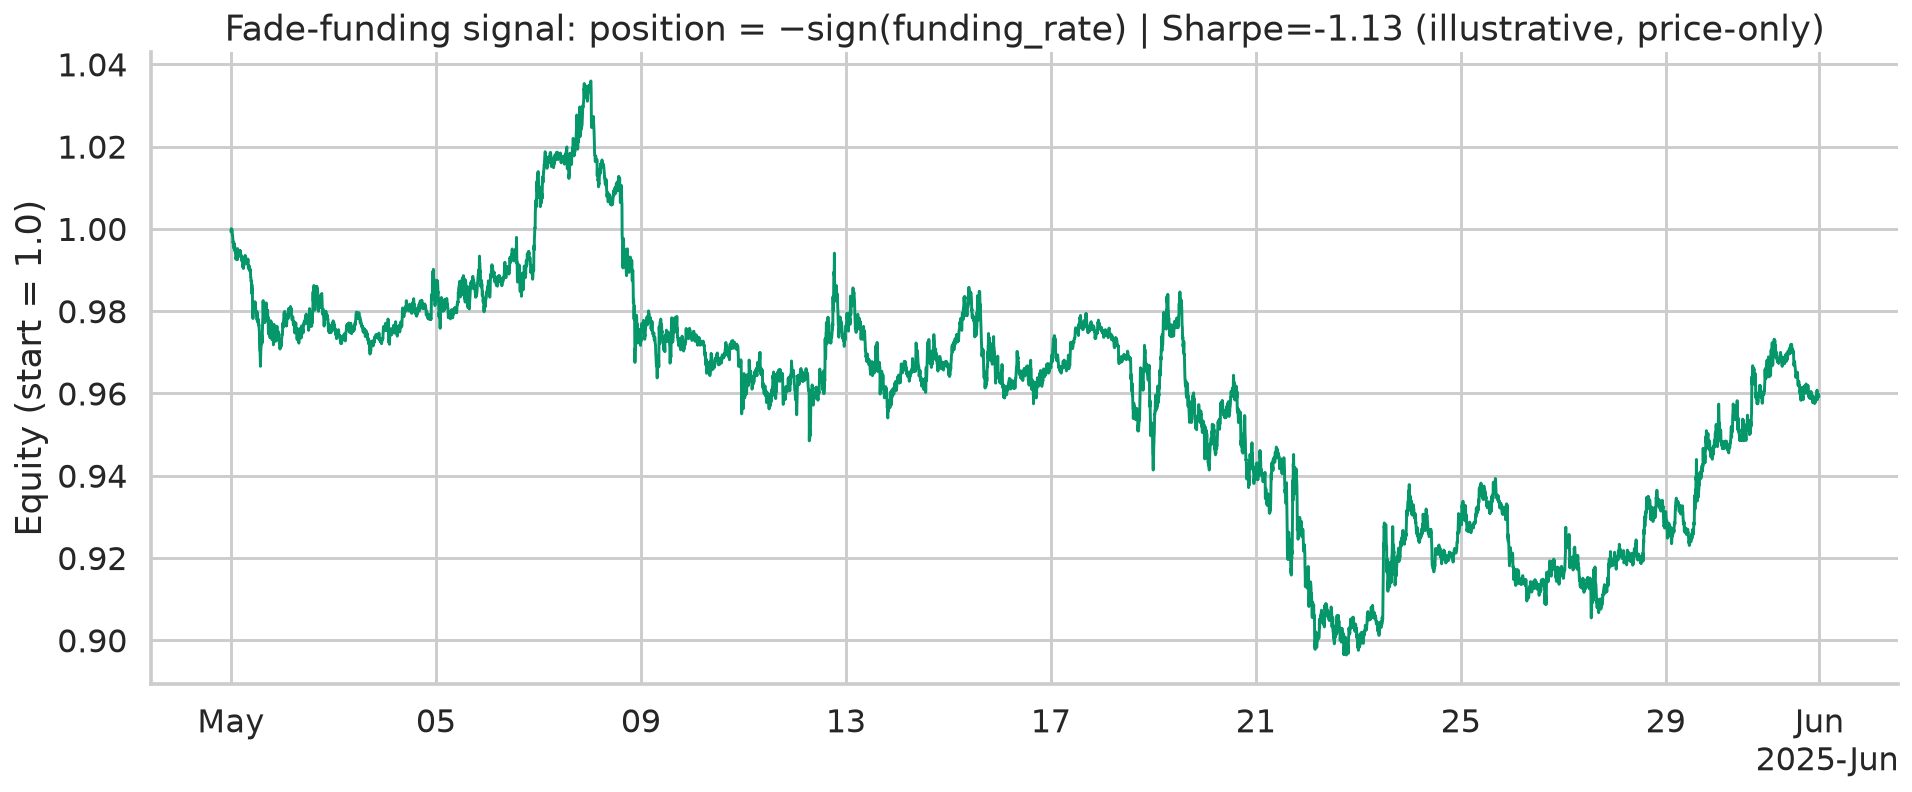

In [9]:
funding_ff = bt["funding_rate_ff"]
signal_pos = -np.sign(funding_ff).fillna(0.0).to_numpy()
valid_s = np.isfinite(signal_pos) & np.isfinite(fret)
frame_s, summ_s = run_position_backtest(
    bt.loc[valid_s, "time"], np.nan_to_num(signal_pos[valid_s]), np.nan_to_num(fret[valid_s]), cost_bps_one_way=0.0
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(frame_s["timestamp"], frame_s["equity_curve"], color="#059669", linewidth=1.5)
ax.set_title(
    f"Fade-funding signal: position = −sign(funding_rate) "
    f"| Sharpe={summ_s['annualized_sharpe']:.2f} (illustrative, price-only)"
)
ax.set_ylabel("Equity (start = 1.0)")
format_time_axis(ax)
plt.tight_layout()
print(
    "Bridge to alpha research only — one month, one instrument, no costs. "
    "See notebooks/alpha-discovery.py for the full search framework."
)

## Takeaways

- **Funding is real PnL.** The gap between the *price-only* and *price + funding*
  curves in Section 6 is carry the price-only backtest silently claimed as alpha.
  The `funding_contribution_pct` column reports its size for the traded position.
- **A constant long pays in bullish, positive-funding regimes.** Chart 2's
  cumulative funding for a unit long shows how much, and when the sign flipped.
- **Realised, not predicted.** Everything here accounts for prints that already
  happened; the catalogue has no predicted-funding metric.
- **One month proves nothing.** The Sharpe/return/drawdown figures — including the
  fade-funding diagnostic — are illustrative, not evidence of persistence.

## Further reading
- [Improve your backtest](https://aperiodic.io/use-cases/improve-your-backtest)
- [Derivatives metrics](https://aperiodic.io/metrics/derivatives)
- Cost-model prerequisite: `notebooks/backtest-slippage.py`
- Related notebook: `notebooks/alpha-discovery.py`